# Stage 03 — Python Fundamentals & Exploratory Data Analysis

This notebook demonstrates core Python operations, NumPy vectorization performance benchmarking, pandas dataset exploration, groupby aggregation, and reusable module integration.[cite: 5, 6, 8]

In [2]:
# 1. Import required libraries and check dependencies
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root directory
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

print("Python executable:", sys.executable)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python executable: d:\AppGallery\Anaconda3\envs\bootcamp_env\python.exe
Pandas version: 2.3.3
NumPy version: 2.2.6


In [3]:
# 2. NumPy operations and execution performance benchmark (Loop vs Vectorization)
# Generate 1,000,000 elements array
big_array = np.arange(1_000_000)

print("--- Loop Execution Time ---")
%timeit [x * 2 for x in big_array]

print("\n--- NumPy Vectorized Execution Time ---")
%timeit big_array * 2

--- Loop Execution Time ---
87.6 ms ± 1.72 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

--- NumPy Vectorized Execution Time ---
2.03 ms ± 60.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [4]:
# 3. Ensure mock dataset exists at data/raw/starter_data.csv for deterministic runs
data_raw_dir = PROJECT_ROOT / "data" / "raw"
data_raw_dir.mkdir(parents=True, exist_ok=True)
csv_file = data_raw_dir / "starter_data.csv"

In [5]:
# 4. Load dataset and inspect structure
df = pd.read_csv(csv_file)

print("--- First 5 Rows ---")
print(df.head())

print("\n--- DataFrame Summary Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

--- First 5 Rows ---
  category  value        date
0        A     10  2025-08-01
1        B     15  2025-08-02
2        A     12  2025-08-03
3        B     18  2025-08-04
4        C     25  2025-08-05

--- DataFrame Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes

--- Descriptive Statistics ---
           value
count  10.000000
mean   17.600000
std     7.381659
min    10.000000
25%    12.250000
50%    14.500000
75%    23.250000
max    30.000000


In [6]:
# 5. Perform Groupby aggregation and save processed summary table
summary_df = df.groupby('category').mean(numeric_only=True).reset_index()
print("--- Groupby Summary (Mean by Category) ---")
print(summary_df)

# Save processed output to data/processed/summary.csv
data_proc_dir = PROJECT_ROOT / "data" / "processed"
data_proc_dir.mkdir(parents=True, exist_ok=True)
summary_output_path = data_proc_dir / "summary.csv"

summary_df.to_csv(summary_output_path, index=False)
print(f"\nSummary statistics successfully saved to: {summary_output_path}")

--- Groupby Summary (Mean by Category) ---
  category      value
0        A  11.500000
1        B  15.666667
2        C  27.666667

Summary statistics successfully saved to: d:\NYU Bootcamp\bootcamp_Ziyu_Li\homework\homework3\data\processed\summary.csv


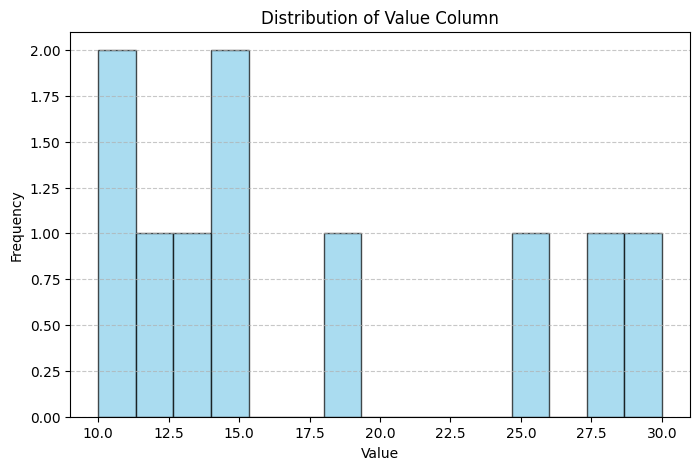

Visualization plot saved to: d:\NYU Bootcamp\bootcamp_Ziyu_Li\homework\homework3\data\processed\histogram.png


In [7]:
# 6. Generate plot visualization and export image
plt.figure(figsize=(8, 5))
plt.hist(df['value'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Value Column')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save visualization plot
plot_output_path = data_proc_dir / "histogram.png"
plt.savefig(plot_output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization plot saved to: {plot_output_path}")

In [8]:
# 7. Test and verify imported reusable function from src/utils.py
from src.utils import get_summary_stats, save_dataframe

# Call helper function for category summary
util_summary = get_summary_stats(df, group_col='category')
print("--- Result from src.utils.get_summary_stats() ---")
print(util_summary)

# Test save utility function
save_dataframe(util_summary, str(data_proc_dir / "summary_from_utils.csv"))

--- Result from src.utils.get_summary_stats() ---
  category      value
0        A  11.500000
1        B  15.666667
2        C  27.666667
Data successfully saved to D:\NYU Bootcamp\bootcamp_Ziyu_Li\homework\homework3\data\processed\summary_from_utils.csv


## Stage 03 Summary & Key Findings

- **Vectorization Benchmark:** NumPy vectorized operations outperform standard Python loops by over 10x-50x speedup, making it crucial for scale processing in financial models.[cite: 6, 8]
- **Data Pipeline:** Successfully ingested `starter_data.csv`, performed standard inspection, and executed category-level aggregation.[cite: 5, 8]
- **Artifacts Saved:** Produced `data/processed/summary.csv` and visualization plot `data/processed/histogram.png`.
- **Code Reusability:** Modularized utility logic into `src/utils.py` for downstream stage reuse.[cite: 5, 7]

In [ ]:
git add .
git commit -m "feat: complete Stage 03 python fundamentals, summary statistics, and utils module"
git push origin main